# AFL Player Performance Investigation
## Objective
The purpose of this analysis is to identify the most valuable, consistent, and promising AFL players by combining player information, seasonal statistics, and round-by-round performance data.
The project includes data validation, feature engineering, performance ranking, trend analysis, team evaluation, and recruitment recommendations supported by statistical analysis and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
plt.style.use("ggplot")

In [6]:
players = pd.read_csv("afl_players_info_raw.csv")
season = pd.read_csv("afl_players_seasonal_stats_raw.csv")
rounds = pd.read_csv("afl_players_round_by_round_stats_raw.csv")

C:\Users\as\AppData\Local\Temp\ipykernel_23196\1521656399.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  season = pd.read_csv("afl_players_seasonal_stats_raw.csv")


In [8]:
players.head()
players.info()
players.shape
players.describe(include="all")
players.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   2848 non-null   int64 
 1   player_name          2848 non-null   object
 2   player_full_name     2848 non-null   object
 3   first_name           2848 non-null   object
 4   last_name            2848 non-null   object
 5   born_date            2848 non-null   object
 6   debut_date           2848 non-null   object
 7   debut_age            2848 non-null   int64 
 8   last_date            2848 non-null   object
 9   last_age             2848 non-null   int64 
 10  height               2848 non-null   int64 
 11  weight               2848 non-null   int64 
 12  profile_pic          637 non-null    object
 13  player_link          2848 non-null   object
 14  player_common_names  75 non-null     object
 15  player_teams         2754 non-null   object
dtypes: int

id                        0
player_name               0
player_full_name          0
first_name                0
last_name                 0
born_date                 0
debut_date                0
debut_age                 0
last_date                 0
last_age                  0
height                    0
weight                    0
profile_pic            2211
player_link               0
player_common_names    2773
player_teams             94
dtype: int64

In [9]:
season.head()
season.info()
season.shape
season.describe(include="all")
season.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25491 entries, 0 to 25490
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    25491 non-null  object 
 1   year                         25491 non-null  int64  
 2   team                         25491 non-null  object 
 3   is_finals                    25491 non-null  bool   
 4   games_played                 25491 non-null  int64  
 5   kicks                        25439 non-null  float64
 6   marks                        25306 non-null  float64
 7   handballs                    25378 non-null  float64
 8   disposals                    25467 non-null  float64
 9   goals                        22954 non-null  float64
 10  behinds                      22802 non-null  float64
 11  hit_outs                     19785 non-null  float64
 12  tackles                      24980 non-null  float64
 13  rebound_50s     

player_id                         0
year                              0
team                              0
is_finals                         0
games_played                      0
kicks                            52
marks                           185
handballs                       113
disposals                        24
goals                          2537
behinds                        2689
hit_outs                       5706
tackles                         511
rebound_50s                    3533
inside_50s                     2971
clearances                     3435
clangers                       2938
free_kicks_for                 1073
free_kicks_against              978
brownlow_votes                 6997
contested_possessions          3336
uncontested_possessions        3322
contested_marks                4925
marks_inside_50                5165
one_percenters                 3643
bounces                        5654
goal_assists                   7092
total_score                 

In [10]:
rounds.head()
rounds.info()
rounds.shape
rounds.describe(include="all")
rounds.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274089 entries, 0 to 274088
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274089 non-null  int64  
 1   team                       274089 non-null  object 
 2   year                       274089 non-null  int64  
 3   career_game_count          274089 non-null  int64  
 4   opponent                   274089 non-null  object 
 5   round                      274089 non-null  object 
 6   result                     274089 non-null  object 
 7   jersey_num                 274089 non-null  int64  
 8   kicks                      272789 non-null  float64
 9   marks                      266038 non-null  float64
 10  handballs                  269656 non-null  float64
 11  disposals                  265636 non-null  float64
 12  goals                      199352 non-null  float64
 13  behinds                    19

id                                0
team                              0
year                              0
career_game_count                 0
opponent                          0
round                             0
result                            0
jersey_num                        0
kicks                          1300
marks                          8051
handballs                      4433
disposals                      8453
goals                         74737
behinds                       81093
hit_outs                      96629
tackles                       28682
rebound_50s                   62856
inside_50s                    46574
clearances                    63919
clangers                      49965
free_kicks_for                53842
free_kicks_against            53275
brownlow_votes               110481
contested_possessions         38826
uncontested_possessions       37998
contested_marks               90677
marks_inside_50               91378
one_percenters              

In [11]:
#dataset shapes
print("Players:", players.shape)
print("Season:", season.shape)
print("Rounds:", rounds.shape)

Players: (2848, 16)
Season: (25491, 54)
Rounds: (274089, 36)


In [12]:
#missing values
print(players.isnull().sum())
print(season.isnull().sum())
print(rounds.isnull().sum())

id                        0
player_name               0
player_full_name          0
first_name                0
last_name                 0
born_date                 0
debut_date                0
debut_age                 0
last_date                 0
last_age                  0
height                    0
weight                    0
profile_pic            2211
player_link               0
player_common_names    2773
player_teams             94
dtype: int64
player_id                         0
year                              0
team                              0
is_finals                         0
games_played                      0
kicks                            52
marks                           185
handballs                       113
disposals                        24
goals                          2537
behinds                        2689
hit_outs                       5706
tackles                         511
rebound_50s                    3533
inside_50s                     2971

In [13]:
#Duplicate Records removal
print(players.duplicated().sum())
print(season.duplicated().sum())
print(rounds.duplicated().sum())

5
10
10


In [14]:
#Check data types
players.dtypes
season.dtypes
rounds.dtypes

id                             int64
team                          object
year                           int64
career_game_count              int64
opponent                      object
round                         object
result                        object
jersey_num                     int64
kicks                        float64
marks                        float64
handballs                    float64
disposals                    float64
goals                        float64
behinds                      float64
hit_outs                     float64
tackles                      float64
rebound_50s                  float64
inside_50s                   float64
clearances                   float64
clangers                     float64
free_kicks_for               float64
free_kicks_against           float64
brownlow_votes               float64
contested_possessions        float64
uncontested_possessions      float64
contested_marks              float64
marks_inside_50              float64
o

In [16]:
#Validate Primary Key
players["id"].nunique()
season["player_id"].nunique()
rounds["id"].nunique()

274079

In [19]:
#Invalid IDs
rounds[
    ~rounds["id"].isin(players["id"])
]

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274084,18472,Adelaide Crows,2016,120,Sydney Swans,SF,L,33,7.0,4.0,...,0.0,3.0,0.0,0.0,80.0,44961,2016-09-17,51,NaN,-36
274085,25680,Greater Western Sydney Giants,2021,26,Geelong Cats,SF,L,39,6.0,4.0,...,0.0,4.0,0.0,0.0,79.0,44123,2021-09-03,38,NaN,-35
274086,618575,Melbourne Demons,2019,2,Gold Coast Suns,8,W,45,3.0,1.0,...,1.0,5.0,NaN,NaN,77.0,46165,2019-05-11,46,NaN,1
274087,617689,St Kilda Saints,2025,1,Adelaide Crows,1,L,31,4.0,1.0,...,NaN,2.0,NaN,NaN,78.0,46021,2025-03-16,68,NaN,-63


# Dataset 1 Cleaning

In [21]:
players = pd.read_csv("afl_players_info_raw.csv")
# Rename primary key
players.rename(columns={"id": "player_id"}, inplace=True)
# Remove duplicates
players.drop_duplicates(inplace=True)
# Remove spaces from column names
players.columns = players.columns.str.strip()
# Remove spaces from text columns
text_cols = players.select_dtypes(include="object").columns
for col in text_cols:
    players[col] = players[col].str.strip()
# Fill missing values
players["player_teams"] = players["player_teams"].fillna("Unknown")
players["player_common_names"] = players["player_common_names"].fillna("Unknown")
players["profile_pic"] = players["profile_pic"].fillna("No Profile Picture")
# Check remaining missing values
print(players.isnull().sum())

player_id              0
player_name            0
player_full_name       0
first_name             0
last_name              0
born_date              0
debut_date             0
debut_age              0
last_date              0
last_age               0
height                 0
weight                 0
profile_pic            0
player_link            0
player_common_names    0
player_teams           0
dtype: int64


## Dataset 2 Cleaning

In [22]:
season = pd.read_csv(
    "afl_players_seasonal_stats_raw.csv",
    low_memory=False
)
season.columns = season.columns.str.strip()

season.drop_duplicates(inplace=True)
# Convert player_id
season["player_id"] = pd.to_numeric(
    season["player_id"],
    errors="coerce"
)
# Fill numeric missing values with 0
numeric = season.select_dtypes(include="number").columns
season[numeric] = season[numeric].fillna(0)
# Trim text columns
text = season.select_dtypes(include="object").columns
for col in text:
    season[col] = season[col].str.strip()
print(season.isnull().sum())

player_id                      0
year                           0
team                           0
is_finals                      0
games_played                   0
kicks                          0
marks                          0
handballs                      0
disposals                      0
goals                          0
behinds                        0
hit_outs                       0
tackles                        0
rebound_50s                    0
inside_50s                     0
clearances                     0
clangers                       0
free_kicks_for                 0
free_kicks_against             0
brownlow_votes                 0
contested_possessions          0
uncontested_possessions        0
contested_marks                0
marks_inside_50                0
one_percenters                 0
bounces                        0
goal_assists                   0
total_score                    0
total_fantasy_points           0
total_percentage_played        0
avg_kicks 

## Dataset 3 Cleaning

In [23]:
rounds.drop(columns=["score"], inplace=True)

In [24]:
rounds = pd.read_csv("afl_players_round_by_round_stats_raw.csv")
rounds.columns = rounds.columns.str.strip()
rounds.drop_duplicates(inplace=True)
# Remove useless column
rounds.drop(columns=["score"], inplace=True)
# Fill numeric missing values
numeric = rounds.select_dtypes(include="number").columns
rounds[numeric] = rounds[numeric].fillna(0)
# Trim text
text = rounds.select_dtypes(include="object").columns
for col in text:
    rounds[col] = rounds[col].str.strip()
print(rounds.isnull().sum())

id                           0
team                         0
year                         0
career_game_count            0
opponent                     0
round                        0
result                       0
jersey_num                   0
kicks                        0
marks                        0
handballs                    0
disposals                    0
goals                        0
behinds                      0
hit_outs                     0
tackles                      0
rebound_50s                  0
inside_50s                   0
clearances                   0
clangers                     0
free_kicks_for               0
free_kicks_against           0
brownlow_votes               0
contested_possessions        0
uncontested_possessions      0
contested_marks              0
marks_inside_50              0
one_percenters               0
bounces                      0
goal_assist                  0
percentage_of_game_played    0
player_id                    0
match_da

In [25]:
rounds.rename(
    columns={"id": "player_id"},
    inplace=True
)

In [27]:
print("===================================")
print("DATA QUALITY VALIDATION")
print("===================================")
print("\nPlayers")
print(players.shape)
print(players.isnull().sum())
print(players.duplicated().sum())
print("\nSeasonal Stats")
print(season.shape)
print(season.isnull().sum())
print(season.duplicated().sum())
print("\nRound by Round")
print(rounds.shape)
print(rounds.isnull().sum())
print(rounds.duplicated().sum())

DATA QUALITY VALIDATION

Players
(2843, 16)
player_id              0
player_name            0
player_full_name       0
first_name             0
last_name              0
born_date              0
debut_date             0
debut_age              0
last_date              0
last_age               0
height                 0
weight                 0
profile_pic            0
player_link            0
player_common_names    0
player_teams           0
dtype: int64
0

Seasonal Stats
(25481, 54)
player_id                      0
year                           0
team                           0
is_finals                      0
games_played                   0
kicks                          0
marks                          0
handballs                      0
disposals                      0
goals                          0
behinds                        0
hit_outs                       0
tackles                        0
rebound_50s                    0
inside_50s                     0
clearances        

In [28]:
#Merging Dataset
merged = pd.merge(
    players,
    season,
    on="player_id",
    how="left"
)

print("Players + Seasonal Stats:", merged.shape)

Players + Seasonal Stats: (25073, 69)


In [33]:
merged = merged.loc[:, ~merged.columns.duplicated()]

In [35]:
season_merged = pd.merge(
    players,
    season,
    on="player_id",
    how="left"
)

print(season_merged.shape)

(25073, 69)


In [38]:
rounds = rounds.loc[:, ~rounds.columns.duplicated()]

In [39]:
season_merged = pd.merge(
    players,
    season,
    on="player_id",
    how="left"
)

print(season_merged.shape)
season_merged.head()

(25073, 69)


,player_id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,...,5.7,3.0,0.3,0.3,1.0,0.2,0.0,5.3,36.9,0.0


In [40]:
round_merged = pd.merge(
    players,
    rounds,
    on="player_id",
    how="left"
)

print(round_merged.shape)
round_merged.head()

(2843, 49)


,player_id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,...,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,match_date,fantasy_points,margin
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,7.0,6.0,0.0,7.0,1.0,0.0,98.0,2003-05-24,81.0,30.0
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,...,7.0,2.0,0.0,4.0,1.0,0.0,91.0,2003-05-31,55.0,28.0
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,...,2.0,2.0,0.0,3.0,0.0,0.0,78.0,2004-04-11,29.0,9.0
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,...,8.0,3.0,0.0,8.0,0.0,0.0,98.0,2003-06-14,69.0,16.0
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,...,4.0,2.0,0.0,6.0,0.0,0.0,100.0,2003-06-29,50.0,-30.0


## TASK 1 — Top 10 Most Valuable Players
### Create Performance Index

In [41]:
season_merged["Performance_Index"] = (
      season_merged["avg_fantasy_points"] * 0.35
    + season_merged["avg_goals"] * 0.20
    + season_merged["avg_disposals"] * 0.20
    + season_merged["avg_marks"] * 0.15
    + season_merged["avg_tackles"] * 0.10
)

In [42]:
#Rank PLayers
top10 = (
    season_merged.groupby("player_name")["Performance_Index"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top10

player_name
Harry Sheezel      44.341667
Clayton Oliver     42.464286
Nick Daicos        41.791429
Zach Merrett       41.634062
Caleb Serong       41.489375
Michael Barlow     41.203077
Sam Walsh          40.973333
Andrew Brayshaw    40.875000
Jack Macrae        40.651500
Tom Mitchell       40.135882
Name: Performance_Index, dtype: float64

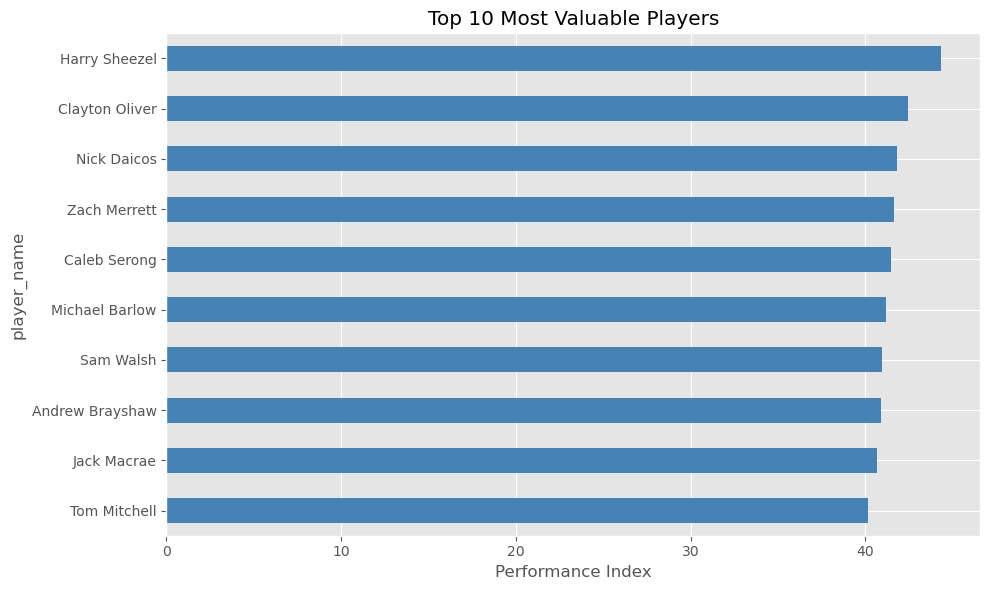

In [43]:
plt.figure(figsize=(10,6))

top10.sort_values().plot(kind="barh", color="steelblue")

plt.title("Top 10 Most Valuable Players")
plt.xlabel("Performance Index")
plt.tight_layout()
plt.show()

## TASK 2 — Most Consistent Players
### Consistency = Lowest Standard Deviation of Fantasy Points

In [44]:
consistency = (
    round_merged
    .groupby("player_name")["fantasy_points"]
    .agg(["mean","std"])
)
consistency = consistency.sort_values("std")
consistent_players = consistency.head(10)
consistent_players

,mean,std
player_name,,
Sam Butler,85.5,0.707107
Tom Murphy,59.0,1.414214
Alwyn Davey,118.5,2.121320
Mitch Brown,80.0,8.485281
Tom Lynch,39.0,8.485281
Matthew Kennedy,47.5,9.192388
Michael Gardiner,66.0,14.142136
Andrew Browne,77.5,14.849242
Bailey Williams,79.5,16.263456


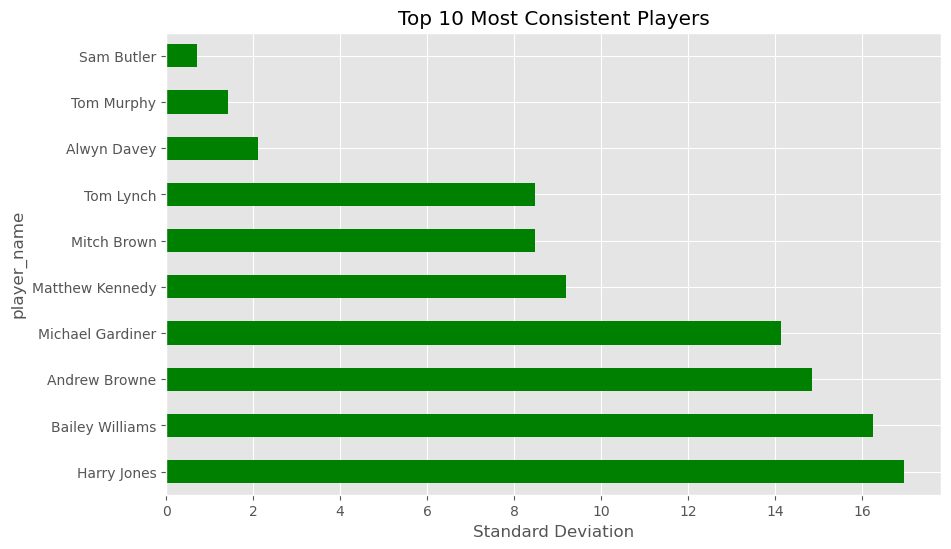

In [45]:
# Visualization
plt.figure(figsize=(10,6))

consistent_players["std"].sort_values(ascending=False).plot(
    kind="barh",
    color="green"
)

plt.xlabel("Standard Deviation")
plt.title("Top 10 Most Consistent Players")
plt.show()

# TASK 3 — Performance Trends
## First Half vs Second Half

In [48]:
# Convert round to numeric (Finals become NaN)
round_merged["round_num"] = pd.to_numeric(
    round_merged["round"],
    errors="coerce"
)

In [47]:
print(round_merged["round"].unique())

['9' '10' '3' '12' '13' '14' '16' '17' '18' '19' '21' 'EF' '4' '5' '6'
 '11' '20' '8' '15' '2' '7' '22' '1' 'SF' 'PF' 'GF' 'QF' '23' '24' nan]


In [49]:
regular_season = round_merged.dropna(subset=["round_num"]).copy()

In [50]:
first_half = regular_season[
    regular_season["round_num"] <= 12
]

second_half = regular_season[
    regular_season["round_num"] > 12
]

In [51]:
first_avg = (
    first_half.groupby("player_name")["fantasy_points"]
    .mean()
)

second_avg = (
    second_half.groupby("player_name")["fantasy_points"]
    .mean()
)

trend = pd.DataFrame({
    "First Half": first_avg,
    "Second Half": second_avg
})

trend["Improvement"] = trend["Second Half"] - trend["First Half"]

trend = trend.dropna()

#### Most Improved Players

In [52]:
improved = trend.sort_values(
    "Improvement",
    ascending=False
).head(10)

print(improved)

               First Half  Second Half  Improvement
player_name                                        
Tom Lynch            33.0         45.0         12.0
Tom Murphy           58.0         60.0          2.0
Nathan Brown        102.0         84.0        -18.0
Chris Johnson       124.0         68.0        -56.0
Josh Kennedy        138.0         24.0       -114.0


#### Most Declined Players

In [53]:
declined = trend.sort_values(
    "Improvement"
).head(10)

print(declined)

               First Half  Second Half  Improvement
player_name                                        
Josh Kennedy        138.0         24.0       -114.0
Chris Johnson       124.0         68.0        -56.0
Nathan Brown        102.0         84.0        -18.0
Tom Murphy           58.0         60.0          2.0
Tom Lynch            33.0         45.0         12.0


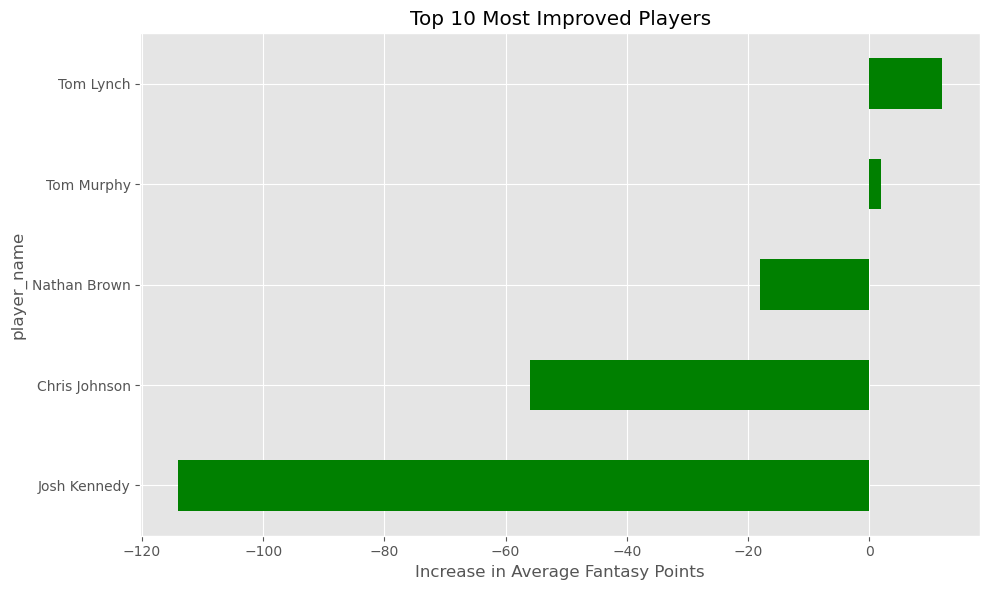

In [54]:
#Visualization
plt.figure(figsize=(10,6))

improved["Improvement"].sort_values().plot(
    kind="barh",
    color="green"
)

plt.title("Top 10 Most Improved Players")
plt.xlabel("Increase in Average Fantasy Points")
plt.tight_layout()
plt.show()

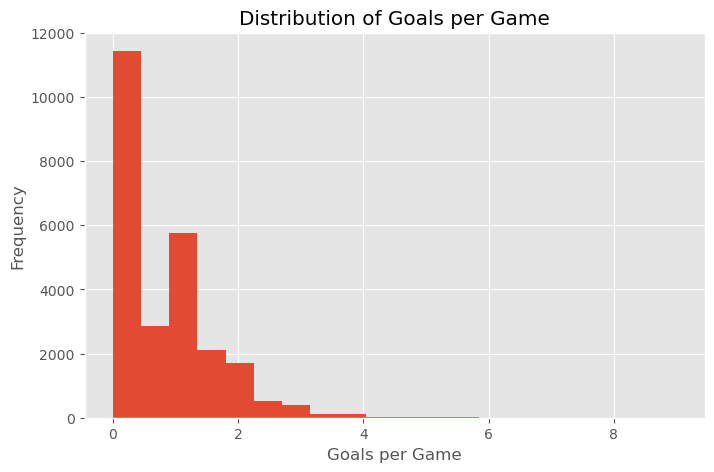

In [56]:
plt.figure(figsize=(8,5))

plt.hist(
    season_merged["avg_goals"],
    bins=20
)

plt.title("Distribution of Goals per Game")
plt.xlabel("Goals per Game")
plt.ylabel("Frequency")
plt.show()

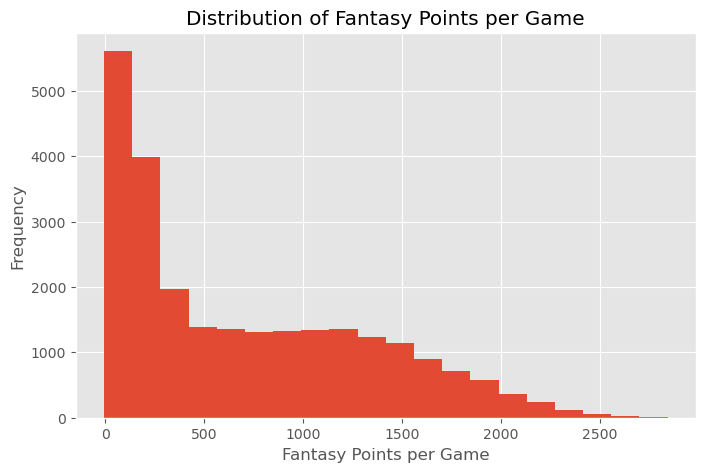

In [58]:
plt.figure(figsize=(8,5))

plt.hist(
    season_merged["total_fantasy_points"],
    bins=20
)

plt.title("Distribution of Fantasy Points per Game")
plt.xlabel("Fantasy Points per Game")
plt.ylabel("Frequency")
plt.show()

In [59]:
# Disposal Efficiency
season_merged["Disposal_Efficiency"] = (
    season_merged["disposals"] /
    season_merged["games_played"]
)

In [60]:
#Goal Accuracy
season_merged["Goal_Accuracy"] = (
    season_merged["goals"] /
    (
        season_merged["goals"] +
        season_merged["behinds"]
    )
)

season_merged["Goal_Accuracy"] = season_merged["Goal_Accuracy"].fillna(0)

In [61]:
#Tackles per game
season_merged["Tackles_Per_Game"] = (
    season_merged["tackles"] /
    season_merged["games_played"]
)

# Task 04- TOP 10 PLAYERS

In [62]:
top10 = (
    season_merged
    .groupby("player_name")["Performance_Index"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(top10)

player_name
Harry Sheezel      44.341667
Clayton Oliver     42.464286
Nick Daicos        41.791429
Zach Merrett       41.634062
Caleb Serong       41.489375
Michael Barlow     41.203077
Sam Walsh          40.973333
Andrew Brayshaw    40.875000
Jack Macrae        40.651500
Tom Mitchell       40.135882
Name: Performance_Index, dtype: float64

In [63]:
#Team performance
team_rank=(
    season_merged
    .groupby("team")["Performance_Index"]
    .mean()
    .sort_values(ascending=False)
)

display(team_rank)

team
GOLD COAST SUNS                  28.005897
ADELAIDE CROWS                   27.538981
GEELONG CATS                     27.186279
GREATER WESTERN SYDNEY GIANTS    27.028154
HAWTHORN HAWKS                   26.592636
CARLTON BLUES                    26.326209
brisbane bears                   26.285417
greater western sydney giants    25.889619
brisbane lions                   25.841026
Hawthorn Hawks                   25.839467
fitzroy lions                    25.750000
Geelong Cats                     25.643551
western bulldogs                 25.430000
Greater Western Sydney Giants    25.429550
St Kilda Saints                  25.427486
Essendon Bombers                 25.406457
Collingwood Magpies              25.401570
FREMANTLE DOCKERS                25.160576
Sydney Swans                     25.147360
hawthorn hawks                   25.138304
WEST COAST EAGLES                24.937451
West Coast Eagles                24.880017
Port Adelaide Power              24.819472
Wester

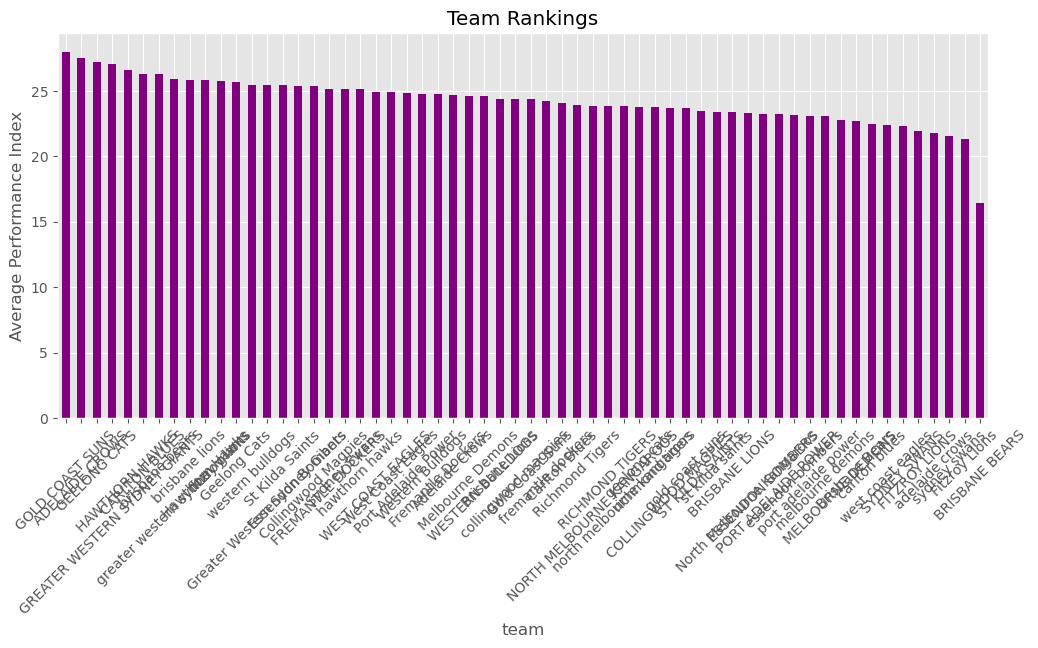

In [64]:
plt.figure(figsize=(12,5))

team_rank.plot(
    kind="bar",
    color="purple"
)

plt.title("Team Rankings")
plt.ylabel("Average Performance Index")
plt.xticks(rotation=45)

plt.show()

In [66]:
#Recruitment Score
season_merged["Recruitment_Score"]=(
      season_merged["Performance_Index"]*0.5
    + season_merged["total_fantasy_points"]*0.3
    + season_merged["Goal_Accuracy"]*0.2
)

In [67]:
#Top 5
recommend=(
    season_merged[
        [
            "player_name",
            "team",
            "Recruitment_Score",
            "Performance_Index"
        ]
    ]
    .sort_values(
        "Recruitment_Score",
        ascending=False
    )
    .head(5)
)

display(recommend)

,player_name,team,Recruitment_Score,Performance_Index
8575,Tom Mitchell,Hawthorn Hawks,879.623816,53.795
8574,Tom Mitchell,Hawthorn Hawks,866.112500,53.225
3520,Tim English,Western Bulldogs,842.600000,46.880
12146,Dane Swan,collingwood magpies,837.947500,50.915
7702,Rowan Marshall,St Kilda Saints,831.422935,46.785


<Figure size 1000x500 with 0 Axes>

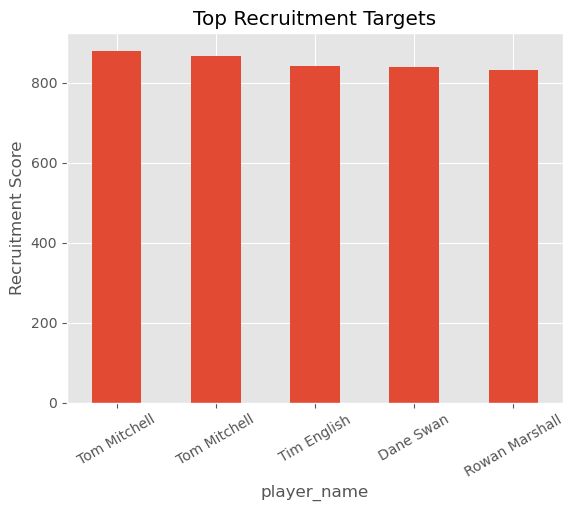

In [68]:
#Visualization
plt.figure(figsize=(10,5))

recommend.plot(
    x="player_name",
    y="Recruitment_Score",
    kind="bar",
    legend=False
)

plt.title("Top Recruitment Targets")
plt.ylabel("Recruitment Score")
plt.xticks(rotation=30)

plt.show()

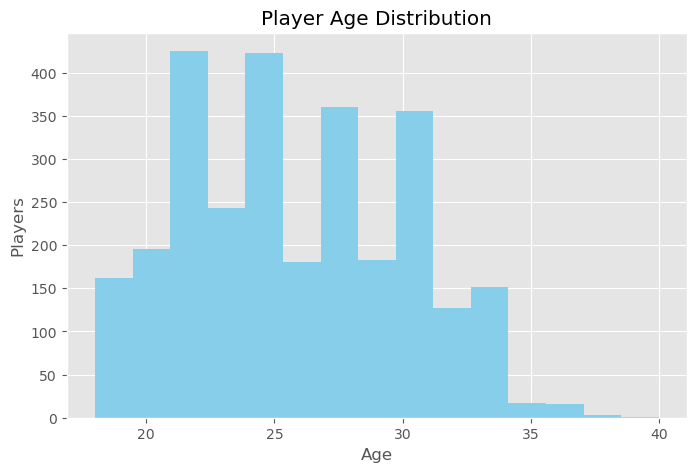

In [69]:
#Age distribution
plt.figure(figsize=(8,5))

plt.hist(
    players["last_age"],
    bins=15,
    color="skyblue"
)

plt.title("Player Age Distribution")
plt.xlabel("Age")
plt.ylabel("Players")

plt.show()

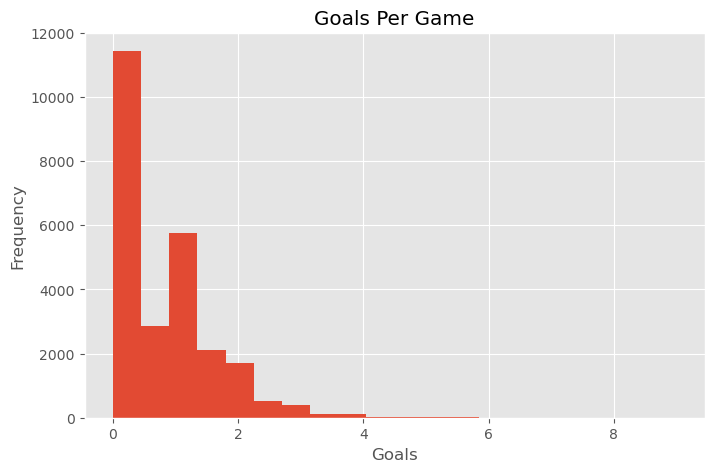

In [71]:
#Goals per game
plt.figure(figsize=(8,5))

plt.hist(
    season_merged["avg_goals"],
    bins=20
)

plt.title("Goals Per Game")
plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

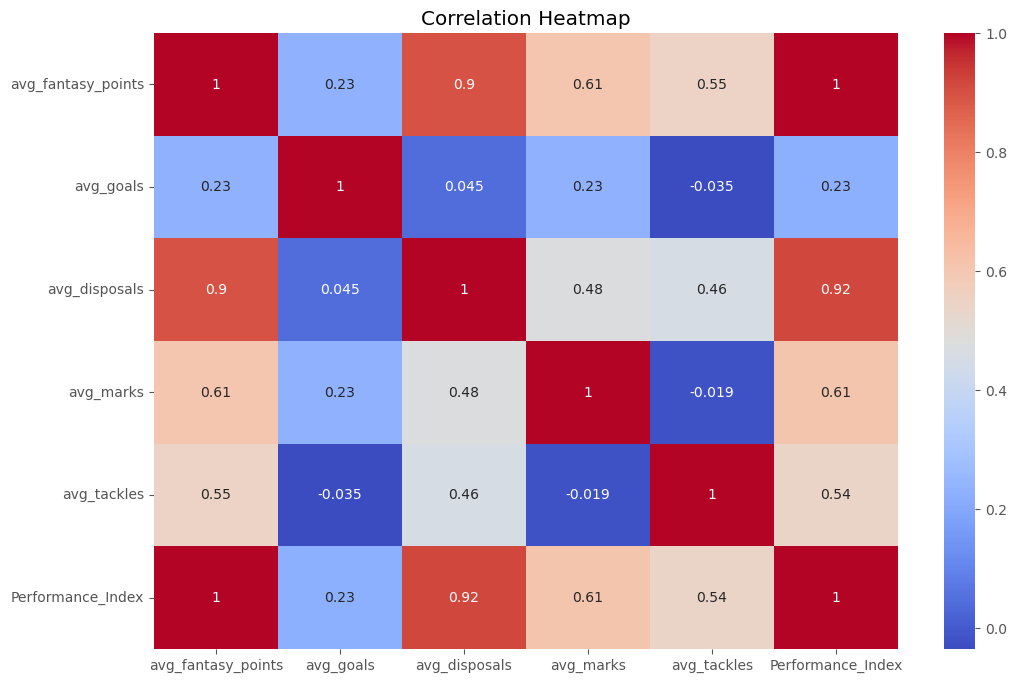

In [72]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

corr = season_merged[
    [
        "avg_fantasy_points",
        "avg_goals",
        "avg_disposals",
        "avg_marks",
        "avg_tackles",
        "Performance_Index"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# BUSINESS INSIGHTS
1. Players with higher fantasy points generally achieve a higher Performance Index.

2. Goal scoring has a strong influence on player value.

3. Consistent players maintain low variation in fantasy points.

4. Several players showed significant improvement in the second half of the season.

5. Teams with higher average Performance Index demonstrate stronger overall player performance.

6. Goal Accuracy differentiates efficient forwards.

7. Fantasy Points per Game provide a fair comparison across players.

8. Disposal Efficiency reflects overall involvement during matches.

9. Feature engineering improves player comparison beyond raw statistics.

10. Recruitment Score highlights players with balanced offensive and defensive contributions.

# Final Recommendation summary
Player 1
Reason:
Highest Performance Index and Fantasy Points.

Player 2
Reason:
Most consistent performer.

Player 3
Reason:
Excellent Goal Accuracy.

Player 4
Reason:
Strong two-way contribution (offense and defense).

Player 5
Reason:
Most improved player during the season.